In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pylab as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [ ]:
img=image.load_img(r"/content/drive/MyDrive/Image_Binary_classification/Training_folder/happy_pic/1536354.jpg")

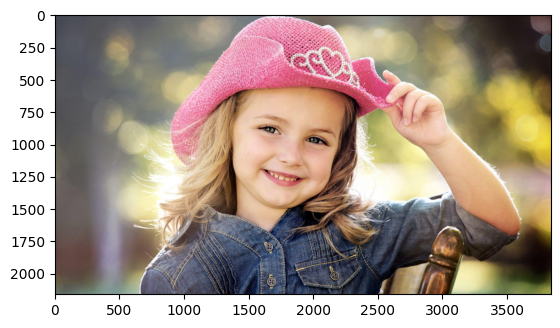

In [ ]:
plt.imshow(img)

In [ ]:
i1= cv2.imread(r"/content/drive/MyDrive/Image_Binary_classification/Training_folder/happy_pic/1536354.jpg")
i1

array([[[ 82,  72,  65],
        [ 82,  72,  65],
        [ 82,  72,  65],
        ...,
        [ 42,  44,  62],
        [ 39,  41,  59],
        [ 37,  39,  57]],

       [[ 82,  72,  65],
        [ 82,  72,  65],
        [ 82,  72,  65],
        ...,
        [ 42,  44,  62],
        [ 40,  42,  60],
        [ 38,  40,  58]],

       [[ 83,  73,  66],
        [ 83,  73,  66],
        [ 83,  73,  66],
        ...,
        [ 43,  45,  63],
        [ 41,  43,  61],
        [ 40,  42,  60]],

       ...,

       [[108, 117, 107],
        [107, 116, 106],
        [106, 115, 105],
        ...,
        [ 78, 168, 162],
        [ 79, 169, 163],
        [ 78, 168, 162]],

       [[109, 118, 108],
        [109, 118, 108],
        [108, 117, 107],
        ...,
        [ 77, 167, 161],
        [ 76, 166, 160],
        [ 75, 165, 159]],

       [[110, 119, 109],
        [109, 118, 108],
        [108, 117, 107],
        ...,
        [ 75, 165, 159],
        [ 74, 164, 158],
        [ 73, 163, 157]]

In [ ]:
i1.shape

(2160, 3840, 3)

In [ ]:
train=ImageDataGenerator(rescale=1/255)
validation=ImageDataGenerator(rescale=1/255)

In [ ]:
train_dataset=train.flow_from_directory(r"/content/drive/MyDrive/Image_Binary_classification/Training_folder",
                                        target_size=(200,200),
                                        batch_size=3,
                                        class_mode='binary')
validation_dataset=validation.flow_from_directory(r"/content/drive/MyDrive/Image_Binary_classification/Testing_folder",
                                                  target_size=(200,200),
                                                  batch_size=3,
                                                  class_mode='binary')

Found 28 images belonging to 2 classes.
Found 28 images belonging to 2 classes.


In [ ]:
train_dataset.class_indices

{'happy_pic': 0, 'sad_pic': 1}

In [ ]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate = 0.001),
              metrics=['acc'])

In [ ]:
model_fit=model.fit(train_dataset,epochs=10)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 727ms/step - acc: 0.3571 - loss: 1.8872
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 487ms/step - acc: 0.6071 - loss: 0.7366
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 550ms/step - acc: 0.6786 - loss: 0.7119
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 602ms/step - acc: 0.7500 - loss: 0.6642
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 482ms/step - acc: 0.6429 - loss: 0.6510
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 625ms/step - acc: 0.7857 - loss: 0.4992
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 524ms/step - acc: 0.8571 - loss: 0.3400
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 480ms/step - acc: 1.0000 - loss: 0.1160
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 670ms/step - acc: 1.0000 - loss: 0.0299
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 471ms/step - acc: 1.0000 - loss: 0.0046


In [ ]:
model_fit=model.fit(train_dataset,
                   steps_per_epoch=3,
                   epochs=10,
                   )

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 663ms/step - acc: 1.0000 - loss: 0.0017
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 499ms/step - acc: 1.0000 - loss: 7.5787e-04
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - acc: 1.0000 - loss: 0.0012    
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 1.0000 - loss: 4.9668e-04  
Epoch 5/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - acc: 1.0000 - loss: 8.0687e-04
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/step - acc: 1.0000 - loss: 1.7338e-04
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 498ms/step - acc: 1.0000 - loss: 3.6419e-04
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 1.4968e-04  
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 548ms/step - acc: 1.0000 - loss: 2.5033e-04
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 796ms/step - acc: 1.0000 - loss: 4.2973e-04


In [ ]:
history = model.fit(
    train_dataset,
    epochs=10,

)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 543ms/step - acc: 1.0000 - loss: 2.5850e-04
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 470ms/step - acc: 1.0000 - loss: 1.3925e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 620ms/step - acc: 1.0000 - loss: 8.8079e-05
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 477ms/step - acc: 1.0000 - loss: 5.6794e-05
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 622ms/step - acc: 1.0000 - loss: 4.0960e-05
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 500ms/step - acc: 1.0000 - loss: 2.9682e-05
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 466ms/step - acc: 1.0000 - loss: 2.0014e-05
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 706ms/step - acc: 1.0000 - loss: 1.5315e-05
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 469ms/step - acc: 1.0000 - loss: 1.3030e-05
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 469ms/step - acc: 1.0000 - loss: 9.3153e-06


In [ ]:
history.history

{'acc': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'loss': [0.00025849955272860825,
  0.00013924897939432412,
  8.807890117168427e-05,
  5.679388777934946e-05,
  4.095983604202047e-05,
  2.9681510568480007e-05,
  2.0013616449432448e-05,
  1.5314728443627246e-05,
  1.3030223271925934e-05,
  9.315271199739072e-06]}

In [ ]:
print(model_fit.history.keys())

dict_keys(['acc', 'loss'])


In [ ]:
print(model_fit.history['acc'])
print(model_fit.history['loss'])

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0016609519952908158, 0.0007578703807666898, 0.0011741076596081257, 0.0004966811975464225, 0.0008068681927397847, 0.00017338139878120273, 0.0003641893563326448, 0.00014968181494623423, 0.0002503268187865615, 0.0004297285049688071]


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - acc: 1.0000 - loss: 4.8687e-06

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 11s/step - acc: 1.0000 - loss: 4.3053e-06 - val_acc: 0.8571 - val_loss: 0.4538
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - acc: 1.0000 - loss: 1.1876e-05 - val_acc: 0.8571 - val_loss: 0.4241
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 926ms/step - acc: 1.0000 - loss: 9.2502e-06 - val_acc: 0.8571 - val_loss: 0.4494
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step - acc: 1.0000 - loss: 2.2852e-06 - val_acc: 0.8571 - val_loss: 0.4493
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - acc: 1.0000 - loss: 5.4023e-06 - val_acc: 0.8214 - val_loss: 0.5128
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - acc: 1.0000 - loss: 8.9280e-06 - val_acc: 0.8571 - val_loss: 0.4382
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - acc: 1.0000 - loss: 5.1006e-06 - val_acc: 0.8571 - val_loss: 0.4375
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step - acc: 1.0000 - loss: 8.6368e-06 - val_acc: 0.8571 - val_loss: 0.4360
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 1.0000 - l

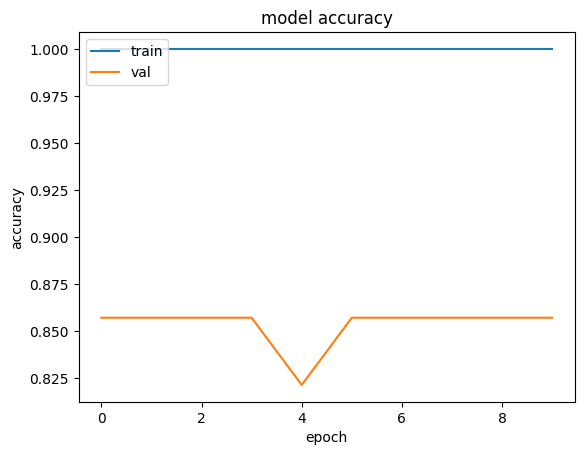

In [ ]:
import keras
from matplotlib import pyplot as plt
#history = model1.fit(train_x, train_y,validation_split = 0.1, epochs=50, batch_size=4)
history=model_fit=model.fit(train_dataset,steps_per_epoch=3,epochs=10,validation_data=validation_dataset)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

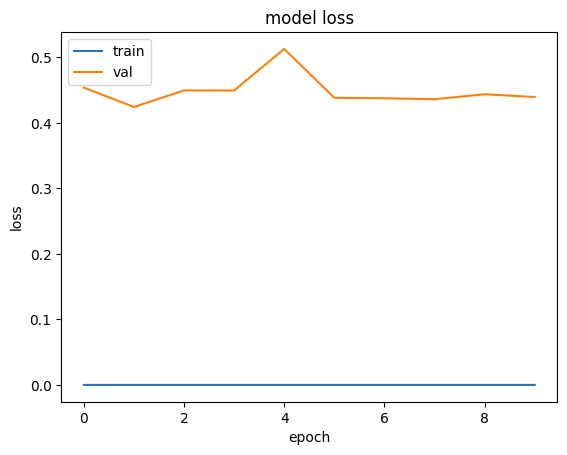

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()